In [661]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn

In [662]:
weather = pd.read_csv("data/Thessaloniki_Weather.csv")

In [663]:
weather

,STATION,NAME,DATE,PRCP,SNWD,TAVG,TMAX,TMIN
0,GRM00016622,"MAKEDONIA, GR",1964-01-03,NaN,NaN,1.9,3.9,1.1
1,GRM00016622,"MAKEDONIA, GR",1964-01-06,NaN,NaN,-0.2,6.1,-2.8
2,GRM00016622,"MAKEDONIA, GR",1964-01-08,NaN,NaN,0.8,7.8,-5.0
3,GRM00016622,"MAKEDONIA, GR",1964-01-09,NaN,NaN,2.4,7.2,-1.1
4,GRM00016622,"MAKEDONIA, GR",1964-01-13,NaN,NaN,-1.2,10.0,-5.0
...,...,...,...,...,...,...,...,...
22881,GRE00155825,"THESSALONIKI, GR",2004-09-11,0.0,NaN,NaN,22.8,11.6
22882,GRE00155825,"THESSALONIKI, GR",2004-09-12,0.0,NaN,NaN,25.0,11.6
22883,GRE00155825,"THESSALONIKI, GR",2004-09-13,0.0,NaN,NaN,26.2,13.4
22884,GRE00155825,"THESSALONIKI, GR",2004-09-14,0.0,NaN,NaN,28.4,14.0


In [664]:
#Core weather is determined by data documentation (in data folder)
core_weather = weather[["DATE", "PRCP", "SNWD", "TMAX", "TMIN"]].copy()
core_weather.columns = ["date", "percip", "snow_depth", "max_temp", "min_temp"]
core_weather = core_weather.set_index('date')
core_weather

,percip,snow_depth,max_temp,min_temp
date,,,,
1964-01-03,NaN,NaN,3.9,1.1
1964-01-06,NaN,NaN,6.1,-2.8
1964-01-08,NaN,NaN,7.8,-5.0
1964-01-09,NaN,NaN,7.2,-1.1
1964-01-13,NaN,NaN,10.0,-5.0
...,...,...,...,...
2004-09-11,0.0,NaN,22.8,11.6
2004-09-12,0.0,NaN,25.0,11.6
2004-09-13,0.0,NaN,26.2,13.4


In [665]:
#We will deal with null values. 2 main tactics: 1. I put the last value of that column wherever null 2. I put zero
#core_weather.index.year.value_counts().sort_index()

In [666]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

percip        0.227432
snow_depth    0.997116
max_temp      0.283317
min_temp      0.365201
dtype: float64

In [667]:
core_weather.apply(pd.isnull).sum()

percip         5205
snow_depth    22820
max_temp       6484
min_temp       8358
dtype: int64

In [668]:
#Only 65 days out of 22885 it snowed so we can delete this column
del core_weather["snow_depth"]

In [669]:
core_weather

,percip,max_temp,min_temp
date,,,
1964-01-03,NaN,3.9,1.1
1964-01-06,NaN,6.1,-2.8
1964-01-08,NaN,7.8,-5.0
1964-01-09,NaN,7.2,-1.1
1964-01-13,NaN,10.0,-5.0
...,...,...,...
2004-09-11,0.0,22.8,11.6
2004-09-12,0.0,25.0,11.6
2004-09-13,0.0,26.2,13.4


In [670]:
core_weather[pd.isnull(core_weather["percip"])]

,percip,max_temp,min_temp
date,,,
1964-01-03,NaN,3.9,1.1
1964-01-06,NaN,6.1,-2.8
1964-01-08,NaN,7.8,-5.0
1964-01-09,NaN,7.2,-1.1
1964-01-13,NaN,10.0,-5.0
...,...,...,...
2020-05-11,NaN,NaN,NaN
2021-02-13,NaN,2.7,NaN
2021-02-21,NaN,13.1,NaN


In [671]:
core_weather["percip"].value_counts()

percip
0.0     14040
0.5       299
1.0       292
0.3       266
2.0       172
        ...  
54.1        1
18.7        1
68.1        1
77.0        1
11.8        1
Name: count, Length: 265, dtype: int64

In [672]:
#Most days it had 0 percip so we can replace null values in percip with 0
core_weather["percip"] = core_weather["percip"].fillna(0)

In [673]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

percip      0.000000
max_temp    0.283317
min_temp    0.365201
dtype: float64

In [674]:
core_weather[pd.isnull(core_weather["max_temp"])]

,percip,max_temp,min_temp
date,,,
1964-01-27,0.0,NaN,-7.2
1964-01-29,0.0,NaN,NaN
1964-12-05,0.0,NaN,NaN
1965-06-30,40.9,NaN,NaN
1965-10-11,0.0,NaN,13.9
...,...,...,...
2023-06-20,0.0,NaN,NaN
2023-06-21,0.0,NaN,NaN
2023-06-23,0.0,NaN,20.8


In [675]:
#Nulls in tmin tmax can be filled with previous known value
core_weather = core_weather.fillna(method="ffill")

In [676]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

percip      0.0
max_temp    0.0
min_temp    0.0
dtype: float64

In [677]:
core_weather

,percip,max_temp,min_temp
date,,,
1964-01-03,0.0,3.9,1.1
1964-01-06,0.0,6.1,-2.8
1964-01-08,0.0,7.8,-5.0
1964-01-09,0.0,7.2,-1.1
1964-01-13,0.0,10.0,-5.0
...,...,...,...
2004-09-11,0.0,22.8,11.6
2004-09-12,0.0,25.0,11.6
2004-09-13,0.0,26.2,13.4


In [678]:
core_weather.dtypes

percip      float64
max_temp    float64
min_temp    float64
dtype: object

In [679]:
#datetime more useful
core_weather.index = pd.to_datetime(core_weather.index)

In [680]:
core_weather.dtypes

percip      float64
max_temp    float64
min_temp    float64
dtype: object

In [681]:
#If x = 9999 then it means null
core_weather.apply(lambda x: (x==9999).sum())

percip      0
max_temp    0
min_temp    0
dtype: int64

<Axes: xlabel='date'>

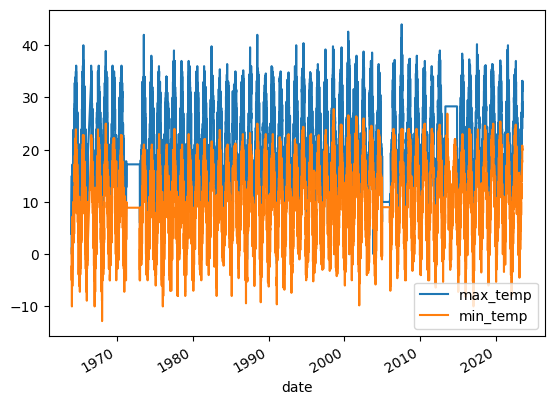

In [682]:
core_weather[["max_temp", "min_temp"]].plot()

In [683]:
core_weather.index.year.value_counts().sort_index()

date
1964    274
1965    359
1966    212
1967    348
1968    366
1969    365
1970    364
1971     90
1973    365
1974    350
1975    364
1976    366
1977    365
1978    365
1979    365
1980    366
1981    365
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    365
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    729
1999    729
2000    732
2001    730
2002    730
2003    730
2004    625
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    362
2022    365
2023    182
Name: count, dtype: int64

In [684]:
#Duplicates in 1998, 1999, 2000, 2001, 2002, 2003, 2004   
core_weather = core_weather.reset_index()
core_weather = core_weather.drop_duplicates(subset=['date'])
core_weather = core_weather.set_index('date')
core_weather

,percip,max_temp,min_temp
date,,,
1964-01-03,0.0,3.9,1.1
1964-01-06,0.0,6.1,-2.8
1964-01-08,0.0,7.8,-5.0
1964-01-09,0.0,7.2,-1.1
1964-01-13,0.0,10.0,-5.0
...,...,...,...
2023-06-28,0.0,33.2,20.0
2023-06-29,0.0,26.2,20.0
2023-06-30,0.8,29.1,20.0


In [685]:
core_weather.index.year.value_counts().sort_index()

date
1964    274
1965    359
1966    212
1967    348
1968    366
1969    365
1970    364
1971     90
1973    365
1974    350
1975    364
1976    366
1977    365
1978    365
1979    365
1980    366
1981    365
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    365
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    365
1999    365
2000    366
2001    365
2002    365
2003    365
2004    366
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    362
2022    365
2023    182
Name: count, dtype: int64

<Axes: xlabel='date'>

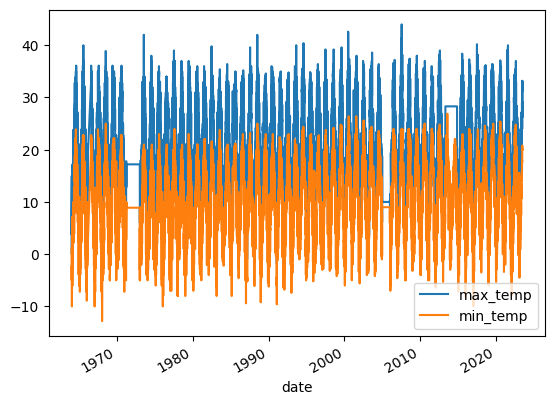

In [686]:
core_weather[["max_temp", "min_temp"]].plot()

In [687]:
#Since we want to predict the next week, 7 targets are set to next 7 days of each day
core_weather["target1"] = core_weather.shift(-1)["max_temp"]
core_weather["target2"] = core_weather.shift(-2)["max_temp"]
core_weather["target3"] = core_weather.shift(-3)["max_temp"]
core_weather["target4"] = core_weather.shift(-4)["max_temp"]
core_weather["target5"] = core_weather.shift(-5)["max_temp"]
core_weather["target6"] = core_weather.shift(-6)["max_temp"]
core_weather["target7"] = core_weather.shift(-7)["max_temp"]
core_weather = core_weather.iloc[:-7, :].copy()
core_weather

,percip,max_temp,min_temp,target1,target2,target3,target4,target5,target6,target7
date,,,,,,,,,,
1964-01-03,0.0,3.9,1.1,6.1,7.8,7.2,10.0,15.0,2.2,0.0
1964-01-06,0.0,6.1,-2.8,7.8,7.2,10.0,15.0,2.2,0.0,2.2
1964-01-08,0.0,7.8,-5.0,7.2,10.0,15.0,2.2,0.0,2.2,7.2
1964-01-09,0.0,7.2,-1.1,10.0,15.0,2.2,0.0,2.2,7.2,8.9
1964-01-13,0.0,10.0,-5.0,15.0,2.2,0.0,2.2,7.2,8.9,8.9
...,...,...,...,...,...,...,...,...,...,...
2023-06-21,0.0,24.0,17.6,33.1,33.1,33.1,31.4,31.4,31.2,33.2
2023-06-22,0.0,33.1,20.0,33.1,33.1,31.4,31.4,31.2,33.2,26.2
2023-06-23,0.0,33.1,20.8,33.1,31.4,31.4,31.2,33.2,26.2,29.1


In [688]:
#Ridge useful when independent variables are highly correlated 
from sklearn.linear_model import Ridge

#Minimizes ||y - Xw||^2_2 + alpha * ||w||^2_2
reg1 = Ridge(alpha=.1)
reg2 = Ridge(alpha=.1)
reg3 = Ridge(alpha=.1)
reg4 = Ridge(alpha=.1)
reg5 = Ridge(alpha=.1)
reg6 = Ridge(alpha=.1)
reg7 = Ridge(alpha=.1)

In [689]:
train = core_weather.loc[:"2021-12-31"]
train

,percip,max_temp,min_temp,target1,target2,target3,target4,target5,target6,target7
date,,,,,,,,,,
1964-01-03,0.0,3.9,1.1,6.1,7.8,7.2,10.0,15.0,2.2,0.0
1964-01-06,0.0,6.1,-2.8,7.8,7.2,10.0,15.0,2.2,0.0,2.2
1964-01-08,0.0,7.8,-5.0,7.2,10.0,15.0,2.2,0.0,2.2,7.2
1964-01-09,0.0,7.2,-1.1,10.0,15.0,2.2,0.0,2.2,7.2,8.9
1964-01-13,0.0,10.0,-5.0,15.0,2.2,0.0,2.2,7.2,8.9,8.9
...,...,...,...,...,...,...,...,...,...,...
2021-12-27,5.1,9.2,7.0,9.2,12.0,13.2,13.2,13.2,13.2,14.2
2021-12-28,1.3,9.2,6.8,12.0,13.2,13.2,13.2,13.2,14.2,14.2
2021-12-29,2.8,12.0,6.8,13.2,13.2,13.2,13.2,14.2,14.2,14.2


In [690]:
#Since future predictions depends of past data, test must be later than train
test = core_weather.loc["2022-01-01":]
test

,percip,max_temp,min_temp,target1,target2,target3,target4,target5,target6,target7
date,,,,,,,,,,
2022-01-01,0.0,13.2,10.0,13.2,14.2,14.2,14.2,13.3,13.0,11.4
2022-01-02,0.0,13.2,10.0,14.2,14.2,14.2,13.3,13.0,11.4,11.0
2022-01-03,0.0,14.2,2.8,14.2,14.2,13.3,13.0,11.4,11.0,12.0
2022-01-04,0.0,14.2,3.0,14.2,13.3,13.0,11.4,11.0,12.0,12.0
2022-01-05,0.0,14.2,3.0,13.3,13.0,11.4,11.0,12.0,12.0,12.0
...,...,...,...,...,...,...,...,...,...,...
2023-06-21,0.0,24.0,17.6,33.1,33.1,33.1,31.4,31.4,31.2,33.2
2023-06-22,0.0,33.1,20.0,33.1,33.1,31.4,31.4,31.2,33.2,26.2
2023-06-23,0.0,33.1,20.8,33.1,31.4,31.4,31.2,33.2,26.2,29.1


In [691]:
predictors = ["percip", "max_temp", "min_temp"]
predictors

['percip', 'max_temp', 'min_temp']

In [692]:
targets = ["target1", "target2", "target3", "target4", "target5", "target6", "target7"]

In [693]:
reg1.fit(train[predictors], train["target1"])
reg2.fit(train[predictors], train["target2"])
reg3.fit(train[predictors], train["target3"])
reg4.fit(train[predictors], train["target4"])
reg5.fit(train[predictors], train["target5"])
reg6.fit(train[predictors], train["target6"])
reg7.fit(train[predictors], train["target7"])


Ridge(alpha=0.1)

In [694]:
predictions1 = reg1.predict(test[predictors])
predictions2 = reg2.predict(test[predictors])
predictions3 = reg3.predict(test[predictors])
predictions4 = reg4.predict(test[predictors])
predictions5 = reg5.predict(test[predictors])
predictions6 = reg6.predict(test[predictors])
predictions7 = reg7.predict(test[predictors])

In [695]:
from sklearn.metrics import mean_absolute_error

In [696]:
mean_absolute_error(test["target1"], predictions1)

1.3003376333278711

In [697]:
mean_absolute_error(test["target2"], predictions2)

2.0426839378192594

In [698]:
mean_absolute_error(test["target3"], predictions3)

2.491090793694298

In [699]:
mean_absolute_error(test["target3"], predictions3)

2.491090793694298

In [700]:
mean_absolute_error(test["target4"], predictions4)

2.764118556013566

In [701]:
mean_absolute_error(test["target5"], predictions5)

2.974052999783747

In [702]:
mean_absolute_error(test["target6"], predictions6)

3.1092307022931935

In [703]:
mean_absolute_error(test["target7"], predictions7)

3.260776770211629

In [704]:
#Score returns the coefficient of determination R^2. It is defined as (1 - u/v), where 
#u is the residual sum of squares ((y_true - y_pred)** 2).sum() and 
#v is the total sum of squares ((y_true - y_true.mean()) ** 2).sum()

score1 = reg1.score(test[predictors], test["target1"])
score2 = reg2.score(test[predictors], test["target2"])
score3 = reg3.score(test[predictors], test["target3"])
score4 = reg4.score(test[predictors], test["target4"])
score5 = reg5.score(test[predictors], test["target5"])
score6 = reg6.score(test[predictors], test["target6"])
score7 = reg7.score(test[predictors], test["target7"])

In [705]:
combined1 = pd.concat([test["target1"], pd.Series(predictions1, index=test.index)] ,axis=1)
combined1.columns = ["actual1", "predictions1"]

combined2 = pd.concat([test["target2"], pd.Series(predictions2, index=test.index)] ,axis=1)
combined2.columns = ["actual2", "predictions2"]

combined3 = pd.concat([test["target3"], pd.Series(predictions3, index=test.index)] ,axis=1)
combined3.columns = ["actual3", "predictions3"]

combined4 = pd.concat([test["target4"], pd.Series(predictions4, index=test.index)] ,axis=1)
combined4.columns = ["actual4", "predictions4"]

combined5 = pd.concat([test["target5"], pd.Series(predictions5, index=test.index)] ,axis=1)
combined5.columns = ["actual5", "predictions5"]

combined6 = pd.concat([test["target6"], pd.Series(predictions6, index=test.index)] ,axis=1)
combined6.columns = ["actual6", "predictions6"]

combined7 = pd.concat([test["target7"], pd.Series(predictions7, index=test.index)] ,axis=1)
combined7.columns = ["actua7", "predictions7"]

<Axes: xlabel='date'>

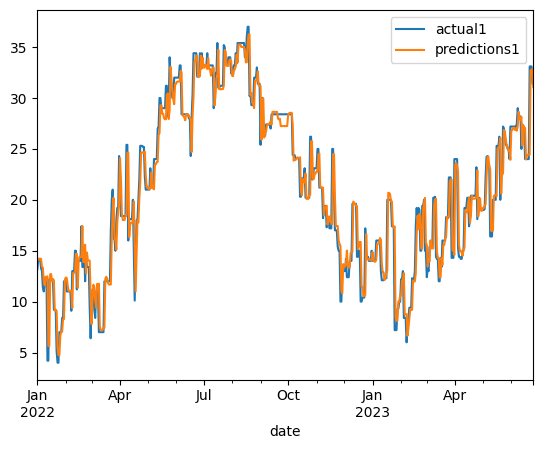

In [706]:
combined1.plot()

<Axes: xlabel='date'>

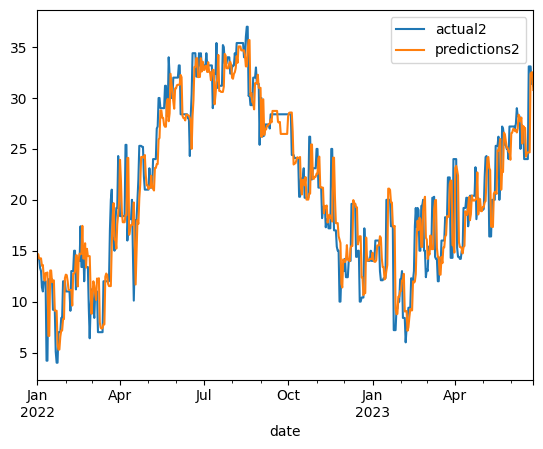

In [707]:
combined2.plot()

<Axes: xlabel='date'>

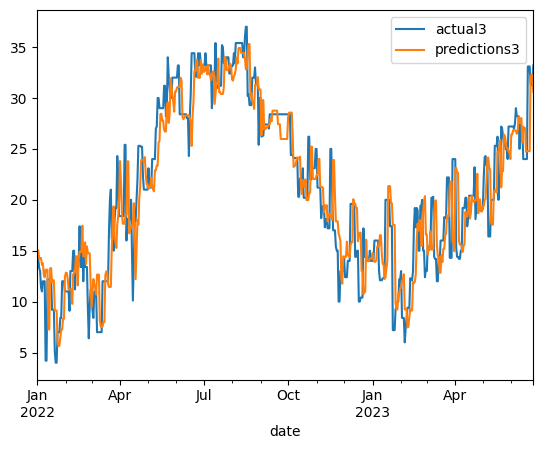

In [708]:
combined3.plot()

<Axes: xlabel='date'>

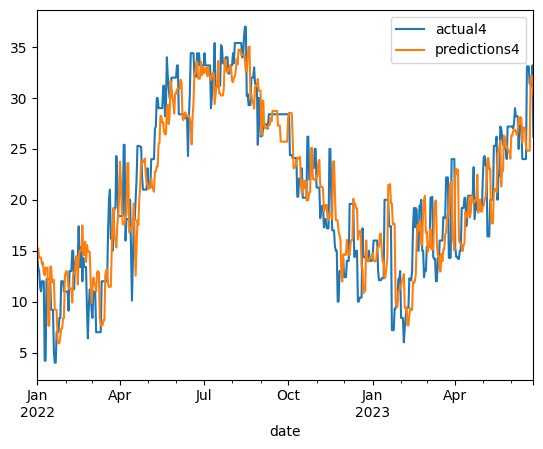

In [709]:
combined4.plot()

<Axes: xlabel='date'>

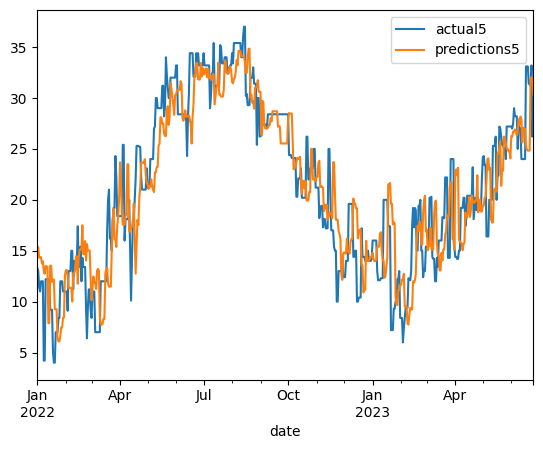

In [710]:
combined5.plot()

<Axes: xlabel='date'>

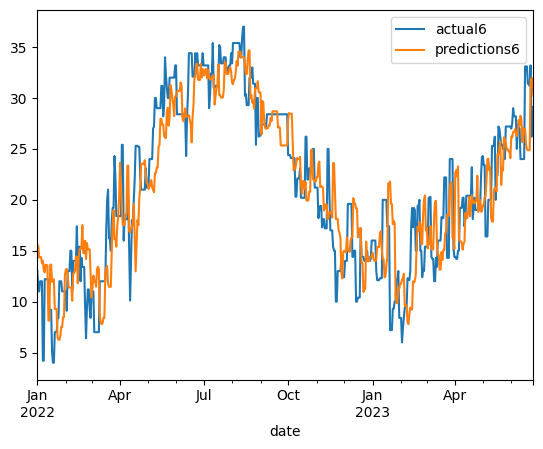

In [711]:
combined6.plot()

<Axes: xlabel='date'>

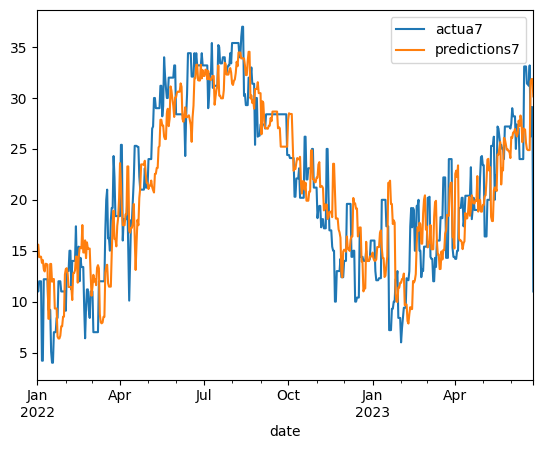

In [712]:
combined7.plot()

In [713]:
reg1.coef_

array([-0.01189352,  0.88232495,  0.10734137])

In [714]:
#Automation
def create_prediction (predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7):
    train = core_weather.loc[:"2021-12-31"]
    test = core_weather.loc["2022-01-01":]

    reg1.fit(train[predictors], train["target1"])
    predictions1 = reg1.predict(test[predictors])
    error1 = mean_absolute_error(test["target1"], predictions1)
    score1 = reg1.score(test[predictors], test["target1"])
    combined1 = pd.concat([test["target1"], pd.Series(predictions1, index=test.index)] ,axis=1)
    combined1.columns = ["actual1", "predictions1"]

    reg2.fit(train[predictors], train["target2"])
    predictions2 = reg2.predict(test[predictors])
    error2 = mean_absolute_error(test["target2"], predictions2)
    score2 = reg2.score(test[predictors], test["target2"])
    combined2 = pd.concat([test["target2"], pd.Series(predictions2, index=test.index)] ,axis=1)
    combined2.columns = ["actual2", "predictions2"]

    reg3.fit(train[predictors], train["target3"])
    predictions3 = reg3.predict(test[predictors])
    error3 = mean_absolute_error(test["target3"], predictions3)
    score3 = reg3.score(test[predictors], test["target3"])
    combined3 = pd.concat([test["target3"], pd.Series(predictions3, index=test.index)] ,axis=1)
    combined3.columns = ["actual3", "predictions3"]

    reg4.fit(train[predictors], train["target4"])
    predictions4 = reg4.predict(test[predictors])
    error4 = mean_absolute_error(test["target4"], predictions4)
    score4 = reg4.score(test[predictors], test["target4"])
    combined4 = pd.concat([test["target4"], pd.Series(predictions4, index=test.index)] ,axis=1)
    combined4.columns = ["actual4", "predictions4"]

    reg5.fit(train[predictors], train["target5"])
    predictions5 = reg5.predict(test[predictors])
    error5 = mean_absolute_error(test["target5"], predictions5)
    score5 = reg5.score(test[predictors], test["target5"])
    combined5 = pd.concat([test["target5"], pd.Series(predictions5, index=test.index)] ,axis=1)
    combined5.columns = ["actual5", "predictions5"]

    reg6.fit(train[predictors], train["target6"])
    predictions6 = reg6.predict(test[predictors])
    error6 = mean_absolute_error(test["target6"], predictions6)
    score6 = reg6.score(test[predictors], test["target6"])
    combined6 = pd.concat([test["target6"], pd.Series(predictions6, index=test.index)] ,axis=1)
    combined6.columns = ["actual6", "predictions6"]

    reg7.fit(train[predictors], train["target7"])
    predictions7 = reg7.predict(test[predictors])
    error7 = mean_absolute_error(test["target7"], predictions7)
    score7 = reg7.score(test[predictors], test["target7"])
    combined7 = pd.concat([test["target7"], pd.Series(predictions7, index=test.index)] ,axis=1)
    combined7.columns = ["actual7", "predictions7"]

    return error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7  

In [715]:
core_weather["avg_max_month"] = core_weather["max_temp"].rolling(30).mean()
core_weather = core_weather.iloc[30:, :].copy()
core_weather

,percip,max_temp,min_temp,target1,target2,target3,target4,target5,target6,target7,avg_max_month
date,,,,,,,,,,,
1964-02-13,0.0,15.0,-2.8,15.0,12.2,12.2,15.0,17.2,17.2,7.8,8.720000
1964-02-14,0.0,15.0,-2.8,12.2,12.2,15.0,17.2,17.2,7.8,7.2,9.016667
1964-02-15,0.0,12.2,3.9,12.2,15.0,17.2,17.2,7.8,7.2,10.0,9.163333
1964-02-16,0.0,12.2,7.2,15.0,17.2,17.2,7.8,7.2,10.0,10.0,9.330000
1964-02-17,0.0,15.0,1.1,17.2,17.2,7.8,7.2,10.0,10.0,12.8,9.496667
...,...,...,...,...,...,...,...,...,...,...,...
2023-06-21,0.0,24.0,17.6,33.1,33.1,33.1,31.4,31.4,31.2,33.2,26.176667
2023-06-22,0.0,33.1,20.0,33.1,33.1,31.4,31.4,31.2,33.2,26.2,26.533333
2023-06-23,0.0,33.1,20.8,33.1,31.4,31.4,31.2,33.2,26.2,29.1,26.730000


In [716]:
core_weather["daily_avg_offset"] = core_weather["avg_max_month"] / core_weather["max_temp"]
core_weather

,percip,max_temp,min_temp,target1,target2,target3,target4,target5,target6,target7,avg_max_month,daily_avg_offset
date,,,,,,,,,,,,
1964-02-13,0.0,15.0,-2.8,15.0,12.2,12.2,15.0,17.2,17.2,7.8,8.720000,0.581333
1964-02-14,0.0,15.0,-2.8,12.2,12.2,15.0,17.2,17.2,7.8,7.2,9.016667,0.601111
1964-02-15,0.0,12.2,3.9,12.2,15.0,17.2,17.2,7.8,7.2,10.0,9.163333,0.751093
1964-02-16,0.0,12.2,7.2,15.0,17.2,17.2,7.8,7.2,10.0,10.0,9.330000,0.764754
1964-02-17,0.0,15.0,1.1,17.2,17.2,7.8,7.2,10.0,10.0,12.8,9.496667,0.633111
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-21,0.0,24.0,17.6,33.1,33.1,33.1,31.4,31.4,31.2,33.2,26.176667,1.090694
2023-06-22,0.0,33.1,20.0,33.1,33.1,31.4,31.4,31.2,33.2,26.2,26.533333,0.801611
2023-06-23,0.0,33.1,20.8,33.1,31.4,31.4,31.2,33.2,26.2,29.1,26.730000,0.807553


In [717]:
core_weather["max_min_ratio"] = core_weather["max_temp"] / core_weather["min_temp"]
core_weather

,percip,max_temp,min_temp,target1,target2,target3,target4,target5,target6,target7,avg_max_month,daily_avg_offset,max_min_ratio
date,,,,,,,,,,,,,
1964-02-13,0.0,15.0,-2.8,15.0,12.2,12.2,15.0,17.2,17.2,7.8,8.720000,0.581333,-5.357143
1964-02-14,0.0,15.0,-2.8,12.2,12.2,15.0,17.2,17.2,7.8,7.2,9.016667,0.601111,-5.357143
1964-02-15,0.0,12.2,3.9,12.2,15.0,17.2,17.2,7.8,7.2,10.0,9.163333,0.751093,3.128205
1964-02-16,0.0,12.2,7.2,15.0,17.2,17.2,7.8,7.2,10.0,10.0,9.330000,0.764754,1.694444
1964-02-17,0.0,15.0,1.1,17.2,17.2,7.8,7.2,10.0,10.0,12.8,9.496667,0.633111,13.636364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-21,0.0,24.0,17.6,33.1,33.1,33.1,31.4,31.4,31.2,33.2,26.176667,1.090694,1.363636
2023-06-22,0.0,33.1,20.0,33.1,33.1,31.4,31.4,31.2,33.2,26.2,26.533333,0.801611,1.655000
2023-06-23,0.0,33.1,20.8,33.1,31.4,31.4,31.2,33.2,26.2,29.1,26.730000,0.807553,1.591346


In [718]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

percip              0.0
max_temp            0.0
min_temp            0.0
target1             0.0
target2             0.0
target3             0.0
target4             0.0
target5             0.0
target6             0.0
target7             0.0
avg_max_month       0.0
daily_avg_offset    0.0
max_min_ratio       0.0
dtype: float64

<Axes: xlabel='date'>

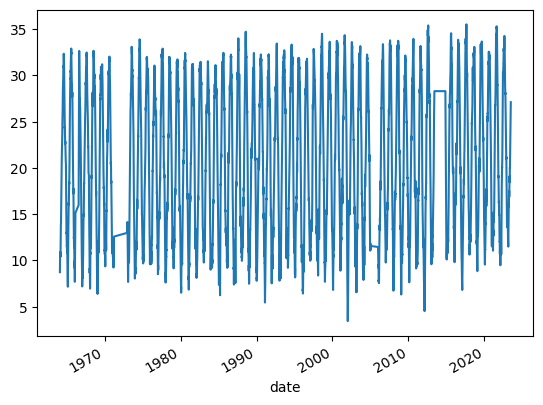

In [719]:
core_weather["avg_max_month"].plot()

<Axes: xlabel='date'>

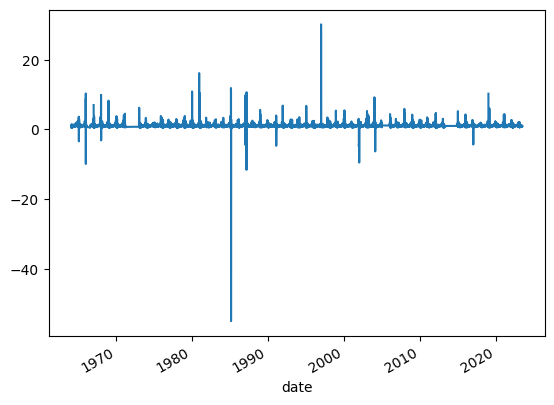

In [720]:
core_weather["daily_avg_offset"].plot()

<Axes: xlabel='date'>

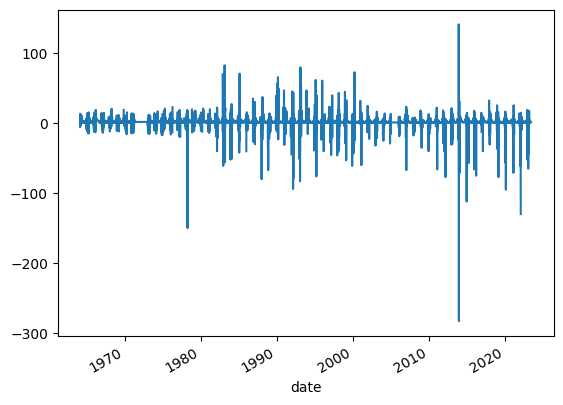

In [721]:
core_weather["max_min_ratio"].plot()

In [722]:
#Infinity doesn't allow prediction
max_dao = core_weather["daily_avg_offset"].max()
min_dao = core_weather["daily_avg_offset"].min()
max_mnr = core_weather["max_min_ratio"].max()
min_mnr = core_weather["max_min_ratio"].min()

max_dao, min_dao, max_mnr, min_mnr

(inf, -54.96666666666667, inf, -283.0)

In [723]:
core_weather = core_weather.reset_index()

core_weather = core_weather.drop(core_weather[core_weather.daily_avg_offset == core_weather["daily_avg_offset"].max()].index)
core_weather = core_weather.drop(core_weather[core_weather.daily_avg_offset == core_weather["daily_avg_offset"].min()].index)

core_weather = core_weather.drop(core_weather[core_weather.max_min_ratio == core_weather["max_min_ratio"].max()].index)
core_weather = core_weather.drop(core_weather[core_weather.max_min_ratio == core_weather["max_min_ratio"].min()].index)

core_weather = core_weather.set_index('date')

<Axes: xlabel='date'>

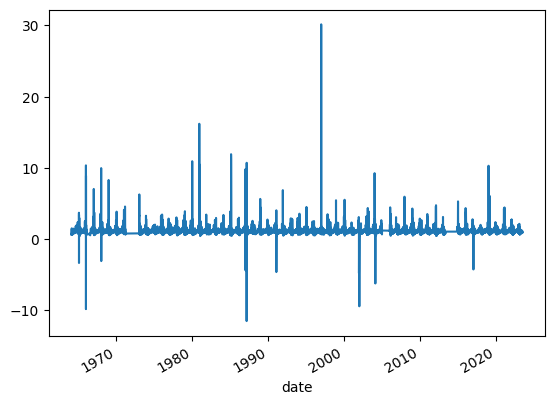

In [724]:
core_weather["daily_avg_offset"].plot()

<Axes: xlabel='date'>

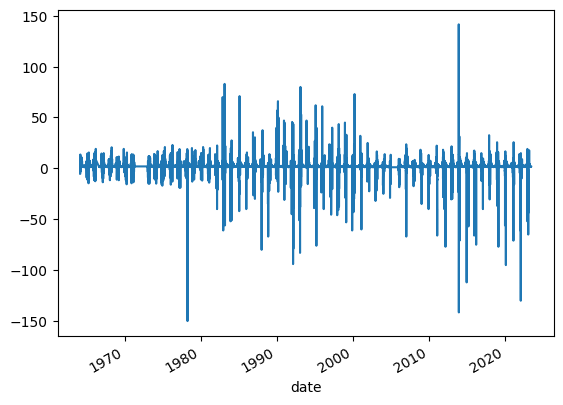

In [725]:
core_weather["max_min_ratio"].plot()

In [726]:
max_dao = core_weather["daily_avg_offset"].max()
min_dao = core_weather["daily_avg_offset"].min()
max_mnr = core_weather["max_min_ratio"].max()
min_mnr = core_weather["max_min_ratio"].min()

max_dao, min_dao, max_mnr, min_mnr

(30.15, -11.58, 141.5, -150.0)

In [727]:
predictors = ["max_temp"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)

3.2834840218992

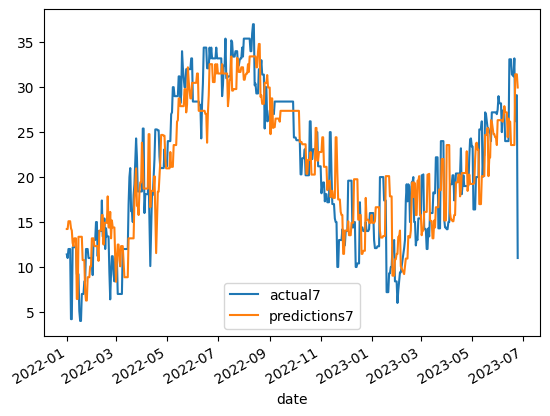

In [728]:
combined7.plot()
error7

In [729]:
predictors = ["percip", "max_temp"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)
error1

1.2700349388341947

3.2937490335718698

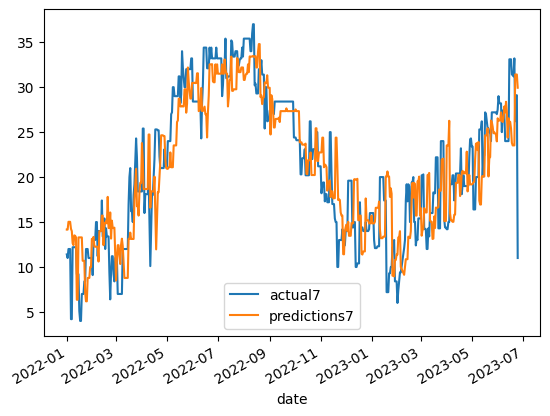

In [730]:
combined7.plot()
error7

In [731]:
predictors = ["percip", "max_temp", "min_temp"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)
error1

1.3005818943010097

3.2735893984537863

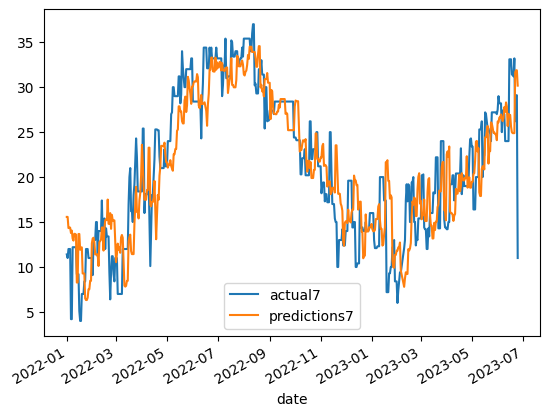

In [732]:
combined7.plot()
error7

In [733]:
predictors = ["percip", "max_temp", "min_temp", "avg_max_month"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)
error1

1.3259230873083372

3.143231920966518

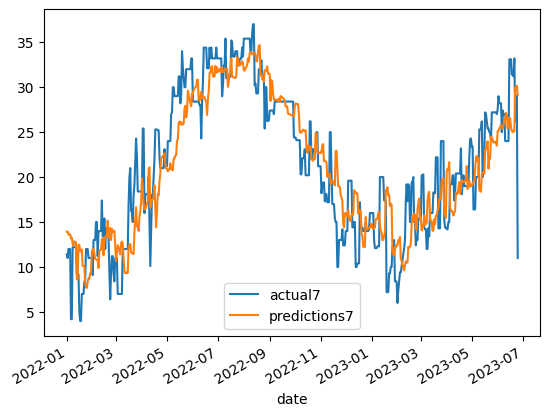

In [734]:
combined7.plot()
error7

In [735]:
predictors = ["percip", "max_temp", "min_temp", "avg_max_month", "daily_avg_offset"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)
error1

1.3263384544542465

3.1380941142212797

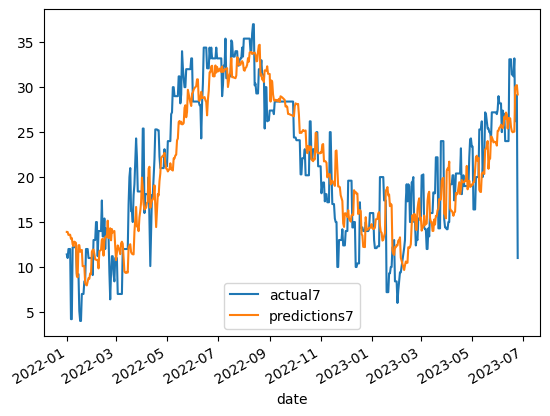

In [736]:
combined7.plot()
error7

In [737]:
predictors = ["percip", "max_temp", "min_temp", "avg_max_month", "daily_avg_offset", "max_min_ratio"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)
error1
reg7.coef_

array([ 0.01414809,  0.50984481,  0.11552849,  0.33280264,  0.2706885 ,
       -0.01278321])

3.1297301225928114

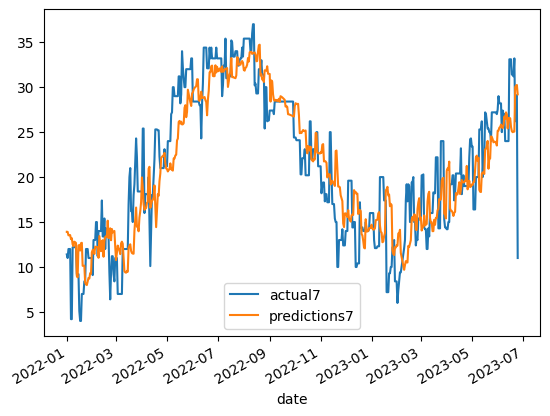

In [738]:
combined7.plot()
error7

1.3263384544542465

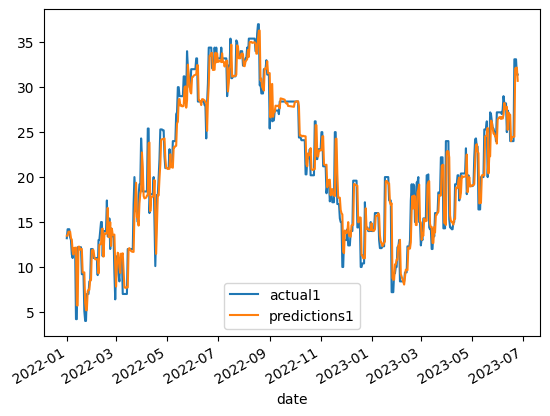

In [739]:
#Better results with these predictors
predictors = ["percip", "max_temp", "min_temp", "avg_max_month", "daily_avg_offset"]
error1, score1, combined1, error2, score2, combined2, error3, score3, combined3, error4, score4, combined4, error5, score5, combined5, error6, score6, combined6, error7, score7, combined7 =create_prediction(predictors, core_weather, reg1, reg2, reg3, reg4, reg5, reg6, reg7)
combined1.plot()
error1

2.018683044844499

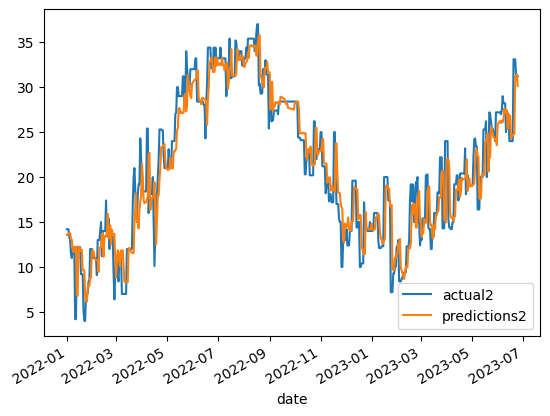

In [740]:
combined2.plot()
error2

2.4204708255023437

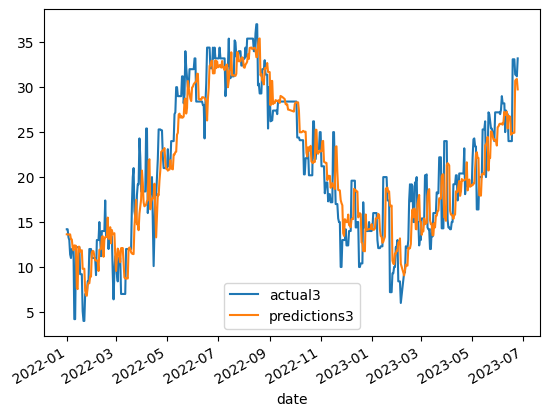

In [741]:
combined3.plot()
error3

2.687654869103055

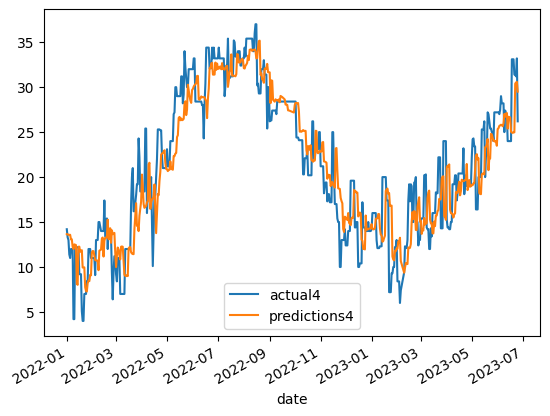

In [742]:
combined4.plot()
error4

2.870738011132447

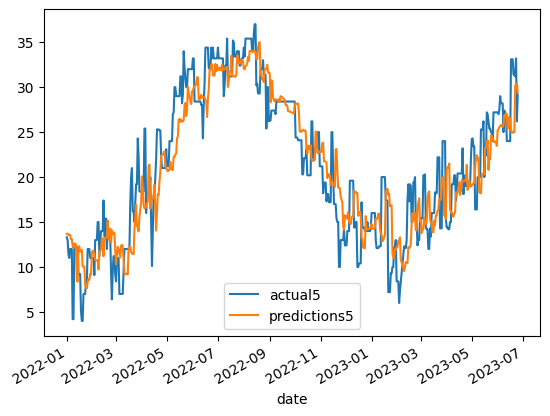

In [743]:
combined5.plot()
error5

3.000444190482442

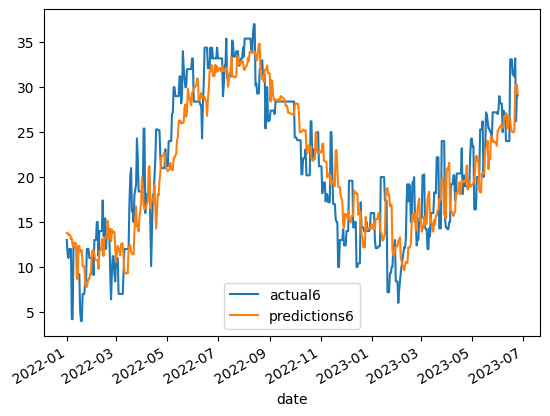

In [744]:
combined6.plot()
error6

3.1380941142212797

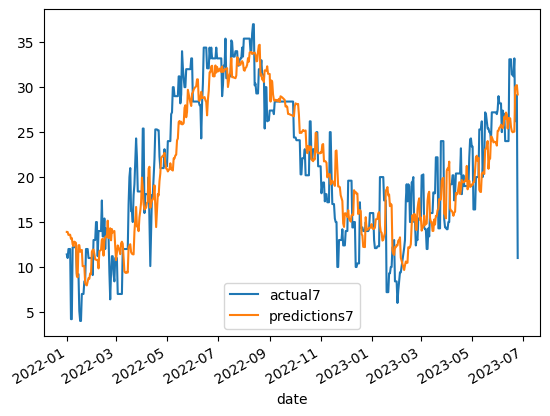

In [745]:
combined7.plot()
error7

In [746]:
#["percip", "max_temp", "min_temp", "avg_max_month", "daily_avg_offset"]
reg7.coef_

array([0.01396811, 0.50856303, 0.11416355, 0.33479445, 0.27341018])

In [747]:
score1

0.9299411869776908

In [748]:
score2

0.8746847561146298

In [749]:
score3

0.8383337984178703

In [750]:
score4

0.8120703116510604

In [751]:
score5

0.7916133408667911

In [752]:
score6

0.7803773174811418

In [753]:
score7

0.7592284512465716